<a href="https://colab.research.google.com/github/PriyaVerma06/EDA-IPL/blob/fix-E7/fix-E7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Issue #4


In [1]:
# 1. Setup and Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load Data

df = pd.read_csv("https://raw.githubusercontent.com/PriyaVerma06/EDA-IPL/main/data/deliveries.csv")

In [3]:
# 3. Handle Missing Values

df["extra_runs"] = df["extra_runs"].fillna(0)
df["extras_type"] = df["extras_type"].fillna("none")

In [4]:
# 4. Filter Valid Innings (1 & 2 only)

df = df[df["inning"].isin([1, 2])]

In [5]:
# 5. Create Extra Type Columns

df["wides"] = df.apply(lambda x: x["extra_runs"] if x["extras_type"] == "wides" else 0, axis=1)
df["noballs"] = df.apply(lambda x: x["extra_runs"] if x["extras_type"] == "noballs" else 0, axis=1)
df["legbyes"] = df.apply(lambda x: x["extra_runs"] if x["extras_type"] == "legbyes" else 0, axis=1)
df["byes"] = df.apply(lambda x: x["extra_runs"] if x["extras_type"] == "byes" else 0, axis=1)


In [6]:
# 6. Group by Team & Inning

extras_summary = df.groupby(["bowling_team", "inning"])[
    ["wides", "noballs", "legbyes", "byes"]
].sum().reset_index()


In [7]:
# 7. Calculate Total & Average Extras

extras_summary["total_extras"] = extras_summary[
    ["wides", "noballs", "legbyes", "byes"]
].sum(axis=1)

# Average extras per match
matches_per_team = df.groupby(["bowling_team", "inning"])["match_id"].nunique().reset_index(name="matches")

extras_summary = extras_summary.merge(matches_per_team, on=["bowling_team", "inning"])
extras_summary["avg_extras"] = extras_summary["total_extras"] / extras_summary["matches"]

print(extras_summary.head())


          bowling_team  inning  wides  noballs  legbyes  byes  total_extras  \
0  Chennai Super Kings       1    488       39      258    49           834   
1  Chennai Super Kings       2    585       63      301    59          1008   
2      Deccan Chargers       1    140       28       92    34           294   
3      Deccan Chargers       2    188       21      123    28           360   
4       Delhi Capitals       1    262       26      114    19           421   

   matches  avg_extras  
0      108    7.722222  
1      130    7.753846  
2       32    9.187500  
3       43    8.372093  
4       50    8.420000  


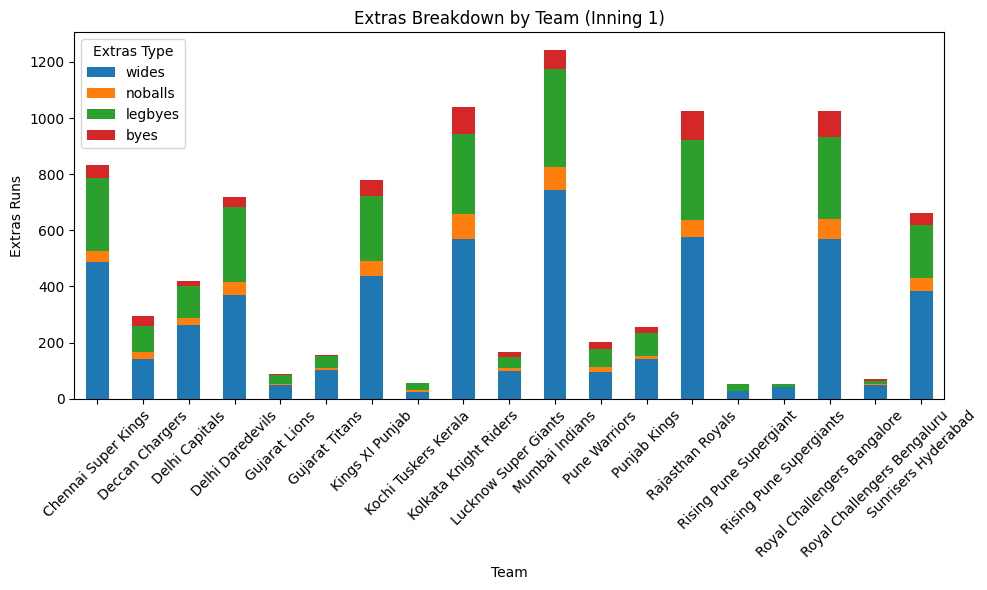

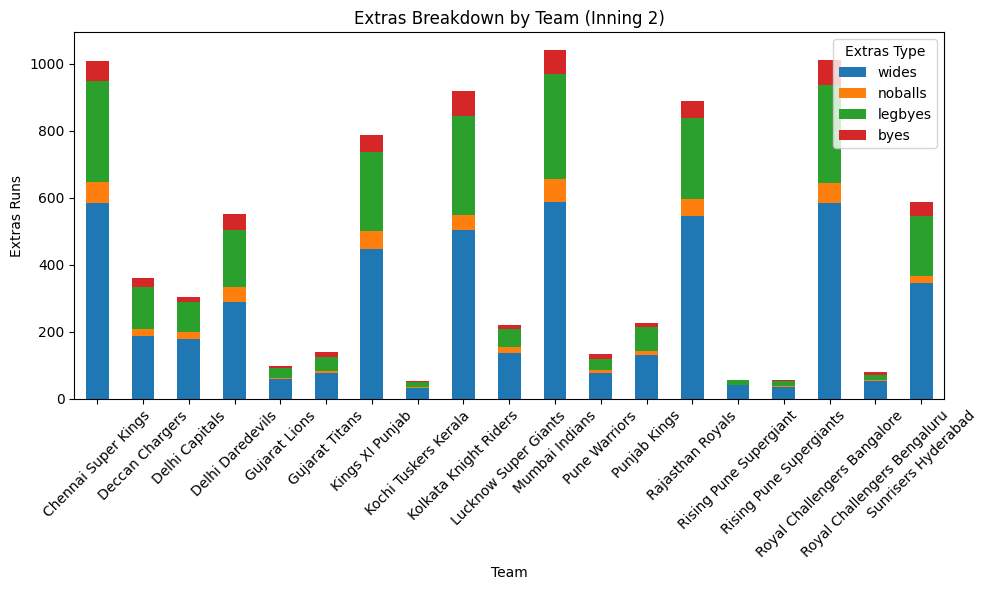

In [8]:
# 8. Visualization (Stacked Bar)

teams = extras_summary["bowling_team"].unique()

for inning in [1, 2]:
    data = extras_summary[extras_summary["inning"] == inning]

    data.set_index("bowling_team")[["wides", "noballs", "legbyes", "byes"]].plot(
        kind="bar",
        stacked=True,
        figsize=(10,6)
    )

    plt.title(f"Extras Breakdown by Team (Inning {inning})")
    plt.xlabel("Team")
    plt.ylabel("Extras Runs")
    plt.xticks(rotation=45)
    plt.legend(title="Extras Type")
    plt.tight_layout()
    plt.show()